# Data Preparation
Reusable functions for static (landscape) and dynamic (perimeter/weather) data preparation. The parameters that the user should define are:

1. Incident name
2. Ignition longitude
3. Ignition latitude
4. Radius in miles (for the initial bounding box)
5. Landscape filepath (e.g., ```landscape.lcp```)

This notebook defines functions for each data preparation step, then demonstrates them with the BORDER 2 fire as an example.

In [1]:
import sys
sys.path.insert(0, 'src')

import numpy as np
import pandas as pd
import geopandas as gpd
import requests
import json
import geojson
from datetime import datetime
import time
from pathlib import Path
from shapely.geometry import box, Point, Polygon
import matplotlib.pyplot as plt
from pyproj import Transformer

import zipfile
from osgeo import gdal, osr
import io
import subprocess
import shapely
from io import StringIO

import contextily as ctx

from config import (
    DATA_DIR, OUTPUT_DIR, 
    FIREMAP_WX_URL,
    FARSITE_CRS,
    LCPMAKE_EXECUTABLE
)
from firemap import fetch_fire_perimeters

# Enable GDAL exceptions
gdal.UseExceptions()
osr.UseExceptions()

In [2]:

# Example: Create a .prj file for WGS 84 (EPSG:4326)
# create_prj_file(5070, 'my_shapefile.prj')

---
# Part 2: Example - Synthetic Fire

## 1.1 Landscape/Domain Functions

In [3]:
def get_fire_detections(bbox, start_date, satellite_source="LANDSAT_NRT", day_range=5, firms_map_key="b38da98e9b7e9389fd05a00c32f99783"):
    """
    Fetch active fire detections from NASA FIRMS API. 
    
    Args:
        firms_map_key (str): Access key to query NASA FIRMS API.
        bbox (str): "minLon, minLat, maxLon, maxLat" (WGS84)
        start_time (str): Start datetime ("%Y-%m-%d")
        satellite_source (str): satelite source name (options: https://firms.modaps.eosdis.nasa.gov/api/area/)
            default: "LANDSAT_NRT" (US/Canada only)
        day_range (int): number between 1-5 of days to query
            default: 5
        
    Returns:
        dict
    """
    minx, miny, maxx, maxy = bbox
    bbox = f"{minx},{miny},{maxx},{maxy}"
    
    # Set up base URL
    FIRMS_API_URL = f"https://firms.modaps.eosdis.nasa.gov/usfs/api/area/csv/{firms_map_key}/{satellite_source}/{bbox}/{day_range}/{start_date}"

    try:
        response = requests.get(FIRMS_API_URL, timeout=30)
        response.raise_for_status()
        print(f"\nNASA FIRMS Satellite Response: {response.url}")
        
        # Parse CSV response
        csv_data = StringIO(response.text)
        
        # Read into DataFrame
        hotspots_df = pd.read_csv(csv_data)
        
        print(f"\n✓ Retrieved {len(hotspots_df)} fire detections")
        
    except requests.exceptions.HTTPError as e:
        if response.status_code == 404:
            print("\n⚠ No fire detections found in this area and time range")
            hotspots_df = pd.DataFrame()
        else:
            print(f"\n❌ API Error: {e}")
            print("Check your MAP_KEY and try again")
            raise

    # Display dataframe keys
    col_names = list(hotspots_df.columns.values)
    print(f"\nData columns:\n{col_names}")


    # Convert to GeoDataFrame with hotspot points
    geometry = [Point(lon, lat) for lon, lat in zip(hotspots_df['longitude'], hotspots_df['latitude'])]
    hotspots_gdf = gpd.GeoDataFrame(
        hotspots_df,
        geometry=geometry,
        crs="EPSG:4326"
    )
    
    return hotspots_gdf

In [4]:
def create_bbox_from_point(lon, lat, radius_km=10.0, write_geojson=False, output_path="initial_bbox.geojson"):
    """
    Create a bounding box (as a buffer polygon) around a geographic point.

    Args:
        lon (float): Longitude of center point (EPSG:4326)
        lat (float): Latitude of center point (EPSG:4326)
        radius_km (float): Radius of the buffer in kilometers
        write_geojson (bool): If True, write output GeoJSON
        output_path (str): Output path for GeoJSON

    Returns:
        GeoDataFrame containing the buffered area (in EPSG:4326)
    """
    # Create center point in WGS84
    center_point = Point(lon, lat)
    point_gdf = gpd.GeoSeries([center_point], crs="EPSG:4326")

    # Convert to a suitable UTM CRS for accurate distance buffering
    utm_crs = point_gdf.estimate_utm_crs()
    point_utm = point_gdf.to_crs(utm_crs)

    # Create buffer (convert km → meters)
    buffer_utm = point_utm.buffer(radius_km * 1000)

    # Convert buffer back to WGS84
    buffer_wgs84 = buffer_utm.to_crs("EPSG:4326")

    # Build GeoDataFrame
    bbox_gdf = gpd.GeoDataFrame(
        {
            "type": ["bounding_box"],
            "radius_km": [radius_km],
        },
        geometry=[buffer_wgs84.iloc[0]],
        crs="EPSG:4326"
    )

    # Optional: Write GeoJSON
    if write_geojson:
        bbox_feature = geojson.Feature(
            geometry=shapely.geometry.mapping(buffer_wgs84.iloc[0]),
            properties={
                "type": "bounding_box",
                "radius_km": radius_km,
                "center_lon": lon,
                "center_lat": lat,
            }
        )
        feature_collection = geojson.FeatureCollection([bbox_feature])
        with open(output_path, "w", encoding="utf-8") as f:
            json.dump(feature_collection, f, indent=2)
        print(f"✓ Bounding box saved to {output_path}")

    return bbox_gdf


def verify_landscape_file(lcp_path):
    """
    Verify that a landscape (.lcp) file exists.
    
    Args:
        lcp_path: Path to landscape file
        
    Returns:
        bool: True if file exists, False otherwise
    """
    exists = Path(lcp_path).exists()
    
    if exists:
        print(f"✓ Landscape file found: {lcp_path}")
    else:
        print(f"✗ Landscape file not found: {lcp_path}")
        print("You need to generate or download a .lcp file for your domain.")
        print("See FARSITE documentation for landscape file creation.")
    
    return exists

def create_prj_file(epsg_code, filename):
    """
    Generates a .prj file for a given EPSG code.
    """
    spatial_ref = osr.SpatialReference()
    # Import the coordinate system from the EPSG code
    if spatial_ref.ImportFromEPSG(epsg_code) == 0:
        # Morph to ESRI WKT format for compatibility
        spatial_ref.MorphToESRI()
        # Export to WKT string
        wkt_string = spatial_ref.ExportToWkt()

        # Write the WKT string to the .prj file
        with open(filename, 'w') as f:
            f.write(wkt_string)
        print(f"Successfully created {filename} for EPSG:{epsg_code}")
    else:
        print(f"Error: Could not import EPSG code {epsg_code}")

def download_landfire_data(
    poly,
    output_dir,
    email,
    verbose=True
):
    """
    Download LANDFIRE landscape data for a fire location.
    
    Args:
        poly: Polygon object (EPSG:4326)
        radius_miles: Radius around center point (miles)
        output_dir: Directory to save downloaded rasters
        email: Valid email address (required by LANDFIRE)
        verbose: Print progress
        
    Returns:
        dict with paths to ASCII rasters:
        {
            'elevation': Path,
            'slope': Path,
            'aspect': Path,
            'fuel': Path,
            'canopy_cover': Path,
            'canopy_height': Path,
            'canopy_base': Path,
            'canopy_density': Path
        }
    """
    """Download LANDFIRE landscape data for a fire location."""
    output_dir = Path(output_dir)
    output_dir.mkdir(exist_ok=True, parents=True)

    # Add buffer to polygon to avoid size error
    buffered_poly = poly.buffer(0.5, cap_style='square')
    
    if verbose:
        print(f"Area of Interest: ({buffered_poly.bounds})")

    minx, miny, maxx, maxy = buffered_poly.bounds
        
    if verbose:
        print(f"Downloading LANDFIRE data in bounding box: [{minx:.4f}, {miny:.4f}, {maxx:.4f}, {maxy:.4f}]")

    
    # Submit LANDFIRE request
    LFPS_URL = "https://lfps.usgs.gov/api/job/submit"
    
    params = {
        "Email": email,
        "Layer_List": "250CBD;250CBH;250CC;250CH;250FBFM40;ASP2020;ELEV2020;SLPP2020",
        "Area_of_Interest": f"{minx} {miny} {maxx} {maxy}",
        "Output_Projection": "5070",  # NAD83 Albers
        "Resample_Resolution": "90",
        "Priority_Code": "K3LS9F"
    }
    
    if verbose:
        print("\nSubmitting LANDFIRE request...")
    
    response = requests.get(LFPS_URL, params=params, timeout=30)
    response.raise_for_status()
    
    job_id = response.json()["jobId"]
    
    if verbose:
        print(f"✓ Job ID: {job_id}")
        print(f"  Notification will be sent to {email}")
    
    # Wait for processing
    status_url = f"https://lfps.usgs.gov/api/job/status?JobId={job_id}"
    print(f"\nLFPS Job Status URL: {status_url}")

    if verbose:
        print("\nWaiting for LANDFIRE processing (takes a couple minutes)...")
    
    start_time = time.time()
    while True:
        response = requests.get(status_url, timeout=30)
        
        status_data = response.json()
        status = status_data.get("status", "").lower()
        
        elapsed = int(time.time() - start_time)
        
        if verbose:
            print(f"  [{elapsed}s] {status}")
        
        if status == "succeeded":
            if verbose:
                print(f"\n✓ Completed in {elapsed}s")
            download_url = status_data["outputFile"]
            break
        elif status in ("failed", "canceled"):
            raise RuntimeError(f"LANDFIRE job {status}: {status_data.get('message', '')}")
        
        time.sleep(10)
    
    # Download and extract
    if verbose:
        print("Downloading...")
    
    zip_response = requests.get(download_url, stream=True, timeout=60)
    zip_response.raise_for_status()
    
    if verbose:
        print("Extracting...")
    
    with zipfile.ZipFile(io.BytesIO(zip_response.content)) as zf:
        zf.extractall(output_dir)
    
    # Convert multi-band TIFF to ASCII rasters
    multi_tif = next(output_dir.glob("*.tif"))
    layer_names = ["250CBD", "250CBH", "250CC", "250CH", "250FBFM40", "ASP2020", "ELEV2020", "SLPP2020"]
    
    if verbose:
        print(f"\nConverting {multi_tif.name} to ASCII rasters...")
    
    for band_idx, layer_name in enumerate(layer_names, start=1):
        asc_path = output_dir / f"{layer_name}.asc"
        gdal.Translate(str(asc_path), str(multi_tif), format="AAIGrid", bandList=[band_idx])
        if verbose:
            print(f"  ✓ {layer_name}.asc")
    
    # Return paths in friendly names
    result = {
        'elevation': output_dir / "ELEV2020.asc",
        'slope': output_dir / "SLPP2020.asc",
        'aspect': output_dir / "ASP2020.asc",
        'fuel': output_dir / "250FBFM40.asc",
        'canopy_cover': output_dir / "250CC.asc",
        'canopy_height': output_dir / "250CH.asc",
        'canopy_base': output_dir / "250CBH.asc",
        'canopy_density': output_dir / "250CBD.asc"
    }
    
    if verbose:
        print(f"\n✓ LANDFIRE data downloaded to {output_dir}/")
    
    return result


def generate_lcp_from_rasters(
    output_path,
    elevation_asc,
    slope_asc,
    aspect_asc,
    fuel_asc,
    canopy_cover_asc,
    canopy_height_asc,
    canopy_base_asc,
    canopy_density_asc,
    latitude=None,
    fuel_model="fb40",
    verbose=True
):
    """
    Generate FARSITE landscape (.lcp) file from ASCII rasters using lcpmake.
    
    Args:
        output_path: Output .lcp file path
        elevation_asc: Elevation raster (.asc) in meters
        slope_asc: Slope raster (.asc) in percent
        aspect_asc: Aspect raster (.asc) in degrees (0-360)
        fuel_asc: Fuel model raster (.asc) - integers matching fuel_model
        canopy_cover_asc: Canopy cover (.asc) in percent (0-100)
        canopy_height_asc: Canopy height (.asc) in meters * 10
        canopy_base_asc: Canopy base height (.asc) in meters * 10
        canopy_density_asc: Canopy bulk density (.asc) in kg/m³ * 100
        latitude: Center latitude in decimal degrees (auto-detected if None)
        fuel_model: Fuel model type - "fb40" (FBFM40) or "fb13" (FBFM13)
        verbose: Print lcpmake command
        
    Returns:
        Path to generated .lcp file
    """
    output_path = Path(output_path)
    lcpmake_exe = Path(LCPMAKE_EXECUTABLE)
    
    if not lcpmake_exe.exists():
        raise FileNotFoundError(
            f"lcpmake executable not found at {lcpmake_exe}\n"
            # f"Place lcpmake in {SCRIPT_DIR}/"
        )
    
    # Auto-detect latitude from elevation raster if not provided
    if latitude is None:
        ds = gdal.Open(str(elevation_asc))
        if ds:
            gt = ds.GetGeoTransform()
            proj = ds.GetProjection()
            x_center = gt[0] + (ds.RasterXSize / 2) * gt[1]
            y_center = gt[3] + (ds.RasterYSize / 2) * gt[5]
            
            src_srs = osr.SpatialReference()
            src_srs.ImportFromWkt(proj)
            dst_srs = osr.SpatialReference()
            dst_srs.ImportFromEPSG(4326)
            transform = osr.CoordinateTransformation(src_srs, dst_srs)
            lon, lat, _ = transform.TransformPoint(x_center, y_center)
            latitude = lat
            ds = None
            if verbose:
                print(f"Auto-detected latitude: {latitude:.4f}")
    
    # Build lcpmake command
    cmd = [
        str(lcpmake_exe),
        "-latitude", str(latitude),
        "-landscape", str(output_path.with_suffix('')),
        "-elevation", str(elevation_asc),
        "-slope", str(slope_asc),
        "-aspect", str(aspect_asc),
        "-fuel", str(fuel_asc),
        "-cover", str(canopy_cover_asc),
        "-height", str(canopy_height_asc),
        "-base", str(canopy_base_asc),
        "-density", str(canopy_density_asc),
    ]
    
    if fuel_model.lower() in ["fb40", "fbfm40", "40"]:
        cmd.append("-fb40")
    elif fuel_model.lower() in ["fb13", "fbfm13", "13"]:
        cmd.append("-fb13")
    else:
        raise ValueError(f"Unknown fuel model: {fuel_model}")
    
    if verbose:
        print("\nRunning lcpmake command:")
        print(" ".join(cmd))
    
    result = subprocess.run(cmd, capture_output=True, text=True)
    
    if result.returncode != 0:
        raise RuntimeError(
            f"lcpmake failed with return code {result.returncode}\n"
            f"stdout: {result.stdout}\nstderr: {result.stderr}"
        )
    
    final_path = output_path.with_suffix('.lcp')
    
    if not final_path.exists():
        raise RuntimeError(f"lcpmake succeeded but output file not found: {final_path}")
    
    if verbose:
        print(f"\n✓ Landscape file created: {final_path}")
        print(f"  Size: {final_path.stat().st_size / 1024:.1f} KB")
    
    return final_path

## 1.2 Perimeter Retrieval Functions

In [5]:
def fetch_fire_perimeters_firms_ogc(fire_name="BORDER 2", bbox=None, 
                                    start_date=None, end_date=None,
                                    fire_id=None, verbose=True):
    """
    Fetch fire perimeters from FIRMS OGC API.
    
    Args:
        fire_name: Name of fire (for display only)
        bbox: Bounding box [minLon, minLat, maxLon, maxLat] in WGS84
        start_date: Start date (YYYY-MM-DD or datetime)
        end_date: End date (YYYY-MM-DD or datetime)
        fire_id: Fire ID to filter (required for accurate results)
        verbose: Print progress
        
    Returns:
        GeoDataFrame with perimeters (already in EPSG:5070, sorted oldest→newest)
    """
    if verbose:
        print(f"Fetching perimeters for: {fire_name}")
        print(f"Data source: FIRMS OGC API (actual perimeter polygons)")
    
    # Border 2 defaults
    if bbox is None:
        bbox = [-117.36, 32.54, -116.04, 33.31]  # San Diego County
    
    if start_date is None:
        start_date = "2025-01-23"
    
    if end_date is None:
        end_date = "2025-01-30"
    
    # Convert dates to ISO format
    if isinstance(start_date, str) and 'T' not in start_date:
        start_date = f"{start_date}T00:00:00"
    if isinstance(end_date, str) and 'T' not in end_date:
        end_date = f"{end_date}T23:59:59"
    
    # Fetch from FIRMS
    from firms_utils import FIRMSPerimeters
    
    client = FIRMSPerimeters()
    perimeters_gdf = client.fetch_fire_perimeters(
        bbox=bbox,
        start_datetime=start_date,
        end_datetime=end_date,
        fire_id=fire_id,
        progress=verbose
    )
    
    # Already sorted oldest→newest and in EPSG:5070
    if verbose:
        print(f"\n✓ Retrieved {len(perimeters_gdf)} perimeter updates")
        print(f"Order: Index 0 = oldest, Index {len(perimeters_gdf)-1} = newest")
    
    return perimeters_gdf

In [6]:
def extract_fire_timeline(perimeters_gdf, verbose=True):
    """
    Extract ignition and containment dates from perimeter GeoDataFrame.
    
    Args:
        perimeters_gdf: GeoDataFrame with perimeter updates (must have 'datetime' column)
        verbose: Print timeline information
        
    Returns:
        dict with keys: 'ignition_date', 'containment_date', 'duration', 'n_updates'
    """
    ignition_date = perimeters_gdf['datetime'].iloc[0]
    containment_date = perimeters_gdf['datetime'].iloc[-1]
    duration = containment_date - ignition_date
    n_updates = len(perimeters_gdf)
    
    timeline = {
        'ignition_date': ignition_date,
        'containment_date': containment_date,
        'duration': duration,
        'n_updates': n_updates
    }
    
    if verbose:
        print(f"\nFire Timeline:")
        print(f"  First observation (ignition): {ignition_date}")
        print(f"  Last observation (containment): {containment_date}")
        print(f"  Total duration: {duration}")
        print(f"  Number of updates: {n_updates}")
    
    return timeline

## 1.3 Weather Data Functions

In [7]:
def fetch_weather_data(lat, lon, start_time, end_time, verbose=True):
    """
    Fetch weather observations from Firemap API.
    
    Args:
        lat: Latitude (WGS84)
        lon: Longitude (WGS84)
        start_time: Start datetime (ISO format string or datetime)
        end_time: End datetime (ISO format string or datetime)
        verbose: Print progress messages
        
    Returns:
        dict with keys: 'location', 'time_range', 'wind_speed', 'wind_direction'
    """
    # Convert datetimes to ISO format if needed
    if isinstance(start_time, pd.Timestamp):
        start_time = start_time.isoformat()
    if isinstance(end_time, pd.Timestamp):
        end_time = end_time.isoformat()
    
    if verbose:
        print(f"Querying weather data...")
        print(f"  Location: {lat:.4f}, {lon:.4f}")
        print(f"  From: {start_time}")
        print(f"  To: {end_time}")
    
    # Query Firemap API
    timestamp = int(time.time() * 1000)
    wx_params = {
        'selection': 'closestTo',
        'lat': str(lat),
        'lon': str(lon),
        'observable': ['wind_speed', 'wind_direction'],
        'from': start_time,
        'to': end_time,
        'callback': 'wxData',
        '_': str(timestamp)
    }
    
    wx_response = requests.get(FIREMAP_WX_URL, params=wx_params)
    wx_text = wx_response.text.strip()
    
    # Remove JSONP wrapper
    if wx_text.startswith('wxData(') and wx_text.endswith(')'):
        wx_json = wx_text[len('wxData('):-1]
        wx_obs = json.loads(wx_json)
    else:
        wx_obs = wx_response.json()
    
    # Extract wind data
    wind_speed_list = wx_obs["features"][0]["properties"]["wind_speed"]
    wind_direction_list = wx_obs["features"][0]["properties"]["wind_direction"]
    
    weather_data = {
        "location": {"lat": lat, "lon": lon},
        "time_range": {"start": start_time, "end": end_time},
        "wind_speed": wind_speed_list,
        "wind_direction": wind_direction_list
    }
    
    if verbose:
        print(f"\n✓ Retrieved {len(wind_speed_list)} weather observations")
        print(f"  Wind speed: {min(wind_speed_list):.1f} - {max(wind_speed_list):.1f} mph (mean: {np.mean(wind_speed_list):.1f})")
        print(f"  Wind direction: {min(wind_direction_list):.0f} - {max(wind_direction_list):.0f}° (mean: {np.mean(wind_direction_list):.0f})")
    
    return weather_data


def get_weather_location_from_fire(perimeters_gdf, to_wgs84=True):
    """
    Get weather query location from fire perimeter centroid.
    
    Args:
        perimeters_gdf: GeoDataFrame with fire perimeters
        to_wgs84: Convert to WGS84 coordinates (required for weather API)
        
    Returns:
        tuple: (lat, lon) in WGS84 if to_wgs84=True, else in original CRS
    """
    # Use first perimeter centroid
    fire_centroid = perimeters_gdf.geometry.iloc[0].centroid
    
    if to_wgs84:
        # Convert to WGS84 for weather API
        transformer = Transformer.from_crs(perimeters_gdf.crs, "EPSG:4326", always_xy=True)
        lon_wgs, lat_wgs = transformer.transform(fire_centroid.x, fire_centroid.y)
        return lat_wgs, lon_wgs
    else:
        return fire_centroid.y, fire_centroid.x

## 1.4 Visualization Functions

In [8]:
def plot_perimeter_evolution(perimeters_gdf, fire_name="Fire", add_basemap=True):
    """
    Plot fire perimeter evolution over time with OpenStreetMap basemap.
    
    Args:
        perimeters_gdf: GeoDataFrame with perimeter updates (must have 'datetime' column)
        fire_name: Name of fire for plot title
        add_basemap: Add OpenStreetMap basemap (default: True)
    """
    fig, ax = plt.subplots(1, 1, figsize=(14, 14))
    
    n_perims = len(perimeters_gdf)
    colors = plt.cm.Reds(np.linspace(0.3, 1, n_perims))
    
    # Plot perimeters
    for idx, (_, row) in enumerate(perimeters_gdf.iterrows()):
        boundary = row.geometry.boundary
        if boundary.geom_type == 'LineString':
            x, y = boundary.xy
            ax.plot(x, y, color=colors[idx], linewidth=2.5, zorder=2)
        elif boundary.geom_type == 'MultiLineString':
            for line in boundary.geoms:
                x, y = line.xy
        ax.plot(x, y, color=colors[idx], linewidth=2.5, zorder=2)
    
    # Add basemap
    if add_basemap:
        try:
            ctx.add_basemap(
                ax=ax, 
                source=ctx.providers.OpenStreetMap.Mapnik, 
                crs=FARSITE_CRS,
                alpha=0.6,
                zorder=1
            )
        except Exception as e:
            print(f"Could not add basemap: {e}")
    
    ax.set_aspect('equal')
    
    start_date = perimeters_gdf['datetime'].iloc[0].date()
    end_date = perimeters_gdf['datetime'].iloc[-1].date()
    ax.set_title(f"{fire_name} - Perimeter Evolution\n{start_date} to {end_date}", fontsize=16, weight='bold')
    
    # Add colorbar
    sm = plt.cm.ScalarMappable(cmap=plt.cm.Reds, norm=plt.Normalize(vmin=0, vmax=n_perims-1))
    sm.set_array([])
    cbar = plt.colorbar(sm, ax=ax, fraction=0.03, pad=0.04)
    cbar.set_label('Time progression (older → newer)', fontsize=12)
    
    plt.tight_layout()
    plt.show()


def plot_weather_data(weather_data):
    """
    Plot weather observations (wind speed and direction).
    
    Args:
        weather_data: Dictionary returned by fetch_weather_data()
    """
    wind_speed = weather_data['wind_speed']
    wind_direction = weather_data['wind_direction']
    
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 6))
    
    ax1.plot(wind_speed, 'b-', linewidth=1)
    ax1.axhline(np.mean(wind_speed), color='r', linestyle='--', 
               label=f'Mean: {np.mean(wind_speed):.1f} mph')
    ax1.set_ylabel('Wind Speed (mph)')
    ax1.set_title('Weather Observations')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    ax2.plot(wind_direction, 'g-', linewidth=1)
    ax2.axhline(np.mean(wind_direction), color='r', linestyle='--', 
               label=f'Mean: {np.mean(wind_direction):.0f}°')
    ax2.set_ylabel('Wind Direction (degrees)')
    ax2.set_xlabel('Observation Index')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()


def plot_active_hotspots(hotspots_gdf):
    # --- Basic info ---
    earliest_date = hotspots_gdf['acq_date'].iloc[0]
    cen_lat = hotspots_gdf['latitude'].iloc[0]
    cen_lon = hotspots_gdf['longitude'].iloc[0]
    cen_point = Point(cen_lat, cen_lon)

    # --- Create figure ---
    fig, ax = plt.subplots(1, 1, figsize=(12, 10))

    # --- Initial invisible plot to determine extent ---
    hotspots_gdf.plot(
        ax=ax,
        color="none",
        markersize=1,
        legend=False
    )

    # --- Expand view ---
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()
    x_margin = (xlim[1] - xlim[0]) * 2.0
    y_margin = (ylim[1] - ylim[0]) * 2.0
    ax.set_xlim(xlim[0] - x_margin, xlim[1] + x_margin)
    ax.set_ylim(ylim[0] - y_margin, ylim[1] + y_margin)

    # --- Basemap ---
    try:
        ctx.add_basemap(
            ax,
            crs=hotspots_gdf.crs.to_string(),
            source=ctx.providers.OpenStreetMap.Mapnik,
            zoom='auto',
            alpha=0.6,
            zorder=0
        )
        print("✓ Basemap added")
    except Exception as e:
        print(f"Note: Could not add basemap: {e}")

    # --- Plot hotspots manually (Matplotlib scatter) ---
    ax.scatter(
        hotspots_gdf.geometry.x,
        hotspots_gdf.geometry.y,
        color='orange',       # uniform hotspot color
        s=200,
        alpha=0.9,
        edgecolors='white',
        linewidths=1.5,
        zorder=10,
        label="Fire Detections"
    )

    # --- Convex hull ---
    hull = hotspots_gdf.unary_union.convex_hull
    gpd.GeoSeries([hull], crs=hotspots_gdf.crs).boundary.plot(
        ax=ax,
        color='red',
        linewidth=3,
        linestyle='--',
        zorder=11,
        label='Fire Extent'
    )

    # --- First and last detections ---
    first = hotspots_gdf.iloc[0]
    last = hotspots_gdf.iloc[-1]

    ax.plot(
        first.geometry.x, first.geometry.y,
        marker='*', markersize=25,
        color='lime', markeredgecolor='black',
        markeredgewidth=2, zorder=15,
        label='First Detection'
    )

    ax.plot(
        last.geometry.x, last.geometry.y,
        marker='*', markersize=25,
        color='red', markeredgecolor='black',
        markeredgewidth=2, zorder=15,
        label='Last Detection'
    )

    # --- Formatting ---
    ax.set_title(
        f"Active Fire Detections near {cen_point} starting {earliest_date}",
        fontsize=14, fontweight='bold'
    )
    ax.set_xlabel("X (m)", fontsize=11)
    ax.set_ylabel("Y (m)", fontsize=11)
    ax.set_aspect("equal")
    ax.grid(True, alpha=0.3, linestyle=":", linewidth=0.5)
    ax.legend(loc='upper right', fontsize=10, framealpha=0.95)

    plt.tight_layout()
    plt.show()

## 1.5 Save/Load Functions

In [9]:
def save_workflow_config(fire_name, lcp_path, timeline, weather_location, 
                        domain_bounds=None, output_path=None):
    """
    Save complete workflow configuration.
    
    Args:
        fire_name: Name of fire
        lcp_path: Path to landscape file
        timeline: Dictionary from extract_fire_timeline()
        weather_location: (lat, lon) tuple
        domain_bounds: Optional domain bounds
        output_path: Output path (default: DATA_DIR/workflow_config.json)
        
    Returns:
        Path to saved configuration file
    """
    config_data = {
        # Static data
        "lcp_path": str(lcp_path),
        "domain_bounds": domain_bounds,
        "crs": FARSITE_CRS,
        
        # Fire information
        "fire_name": fire_name,
        "ignition_date": timeline['ignition_date'].isoformat(),
        "containment_date": timeline['containment_date'].isoformat(),
        "n_perimeters": timeline['n_updates'],
        
        # Weather location
        "weather_location": {"lat": weather_location[0], "lon": weather_location[1]},
    }
    
    if output_path is None:
        output_path = DATA_DIR / "workflow_config.json"
    
    with open(output_path, 'w') as f:
        json.dump(config_data, f, indent=2)
    
    print(f"✓ Configuration saved to {output_path}")
    return output_path


def save_perimeters(perimeters_gdf, fire_name, output_dir=None):
    """
    Save perimeter GeoDataFrame to file.
    
    Args:
        perimeters_gdf: GeoDataFrame with perimeters
        fire_name: Name of fire
        output_dir: Output directory (default: OUTPUT_DIR)
        
    Returns:
        Path to saved file
    """
    if output_dir is None:
        output_dir = OUTPUT_DIR
    
    filename = f"{fire_name.lower().replace(' ', '_')}_perimeters.geojson"
    output_path = output_dir / filename
    
    perimeters_gdf.to_file(output_path, driver="GeoJSON")
    
    print(f"✓ Perimeters saved to {output_path}")
    print(f"  Order: Index 0 = oldest (ignition), Index {len(perimeters_gdf)-1} = newest (containment)")
    
    return output_path


def save_weather_data(weather_data, output_dir=None):
    """
    Save weather data to JSON file.
    
    Args:
        weather_data: Dictionary from fetch_weather_data()
        output_dir: Output directory (default: DATA_DIR)
        
    Returns:
        Path to saved file
    """
    if output_dir is None:
        output_dir = DATA_DIR
    
    output_path = output_dir / "weather_observations.json"
    
    with open(output_path, 'w') as f:
        json.dump(weather_data, f, indent=2)
    
    print(f"✓ Weather data saved to {output_path}")
    
    return output_path

---
# Part 2: Example - Synthetic Fire

Demonstration of complete workflow using synthetically generated fire data.

## 2.1 Define Fire Parameters

In [10]:
# BORDER 2 fire parameters
FIRE_NAME = "Border 2 Synthetic"
IGNITION_LON = -116.88  # Approximate ignition point
IGNITION_LAT = 32.61
IGNITION_DATE = "2025-01-23"
RADIUS_KM = 10  # Bounding box radius
LCP_PATH = "landscape.lcp"  # Path to landscape file

print(f"Configuration:")
print(f"  Fire name: {FIRE_NAME}")
print(f"  Ignition point: ({IGNITION_LAT}, {IGNITION_LON})")
print(f"  Ignition date: {IGNITION_DATE}")
print(f"  Domain radius: {RADIUS_KM} km")
print(f"  Landscape file: {LCP_PATH}")



Configuration:
  Fire name: Border 2 Synthetic
  Ignition point: (32.61, -116.88)
  Ignition date: 2025-01-23
  Domain radius: 10 km
  Landscape file: landscape.lcp


## 2.2 Retrieve Satellite Fire Detections

In [11]:
# Define bounding box around ignition point
bbox_gdf = create_bbox_from_point(
    lon=IGNITION_LON,
    lat=IGNITION_LAT,
    radius_km=RADIUS_KM,
    write_geojson=True,
    output_path=OUTPUT_DIR / "SyntheticFire_bbox.geojson"
)
bbox = bbox_gdf.total_bounds
print(f"\nBounding box bounds (EPSG:4326): {bbox}")


# Retrieve active fire detections from NASA satellites
hotspots_gdf = get_fire_detections(bbox, IGNITION_DATE, day_range=1)

✓ Bounding box saved to /home/jovyan/work/WIFIRE-Digital-Twinners/wildfire-digital-twin/outputs/SyntheticFire_bbox.geojson

Bounding box bounds (EPSG:4326): [-116.98658176   32.51979014 -116.77341878   32.70020856]

NASA FIRMS Satellite Response: https://firms.modaps.eosdis.nasa.gov/usfs/api/area/csv/b38da98e9b7e9389fd05a00c32f99783/LANDSAT_NRT/-116.9865817551599,32.51979014029865,-116.77341878208908,32.70020856190265/1/2025-01-23

✓ Retrieved 4 fire detections

Data columns:
['latitude', 'longitude', 'path', 'row', 'scan', 'track', 'acq_date', 'acq_time', 'satellite', 'confidence', 'daynight']


✓ Basemap added


/tmp/ipykernel_13075/1712577871.py:141: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  hull = hotspots_gdf.unary_union.convex_hull


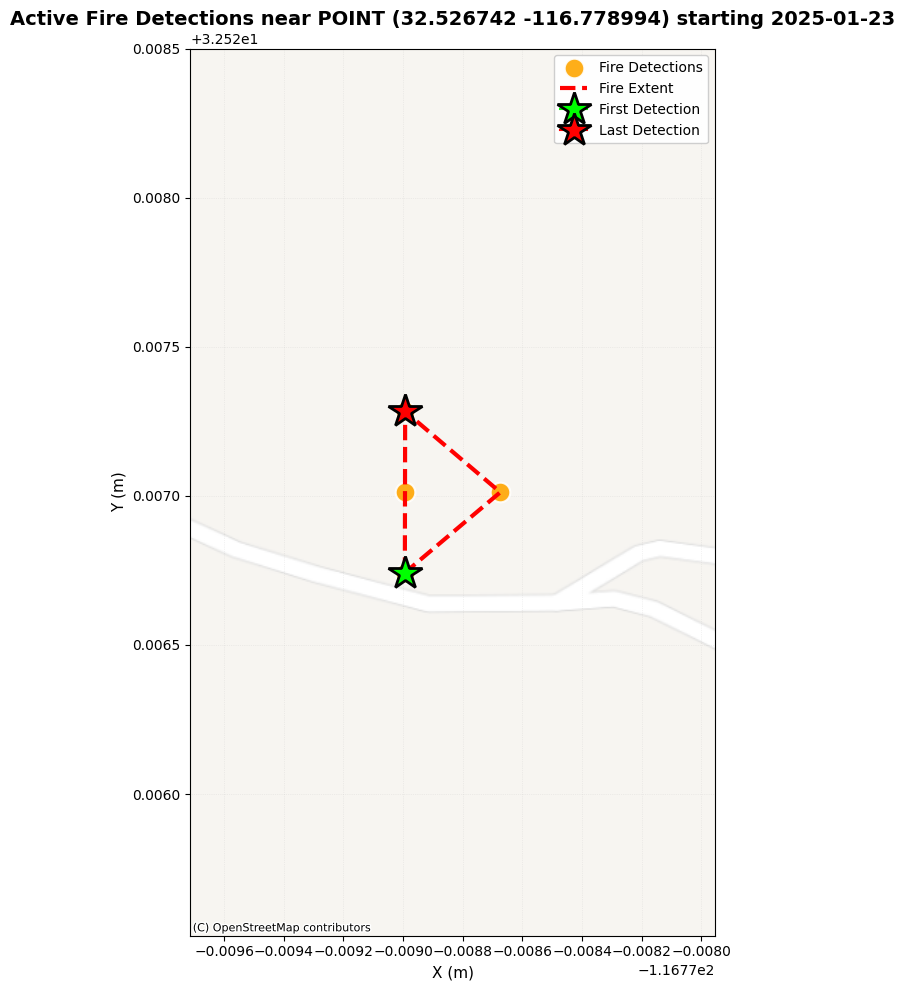

In [12]:
plot_active_hotspots(hotspots_gdf)

In [13]:
IGNITION_POLY = hotspots_gdf.union_all().convex_hull
list(IGNITION_POLY.bounds)

[-116.778994, 32.526742, -116.778674, 32.527283]

## 2.3 Verify Landscape File

In [14]:
# Check if landscape file exists
lcp_exists = verify_landscape_file(LCP_PATH)

✓ Landscape file found: landscape.lcp


In [15]:
# Generate landscape file if necessary
landfire_data = download_landfire_data(
                poly=IGNITION_POLY,
                output_dir=DATA_DIR / "landfire",
                email="tcaglar@ucsd.edu")

Area of Interest: ((-117.2789931458299, 32.02676189093514, -116.27867470837724, 33.02724464106766))

Submitting LANDFIRE request...
✓ Job ID: e7fd5a24-f25d-40cf-8205-a123e6e33ea0
  Notification will be sent to tcaglar@ucsd.edu

LFPS Job Status URL: https://lfps.usgs.gov/api/job/status?JobId=e7fd5a24-f25d-40cf-8205-a123e6e33ea0

Waiting for LANDFIRE processing (takes a couple minutes)...
  [0s] pending
  [10s] executing
  [21s] executing
  [31s] succeeded

✓ Completed in 31s
Downloading...
Extracting...

Converting jbfcd5c577a84469183ffed3f115dab72.tif to ASCII rasters...


Warning 1: PROJ: proj_create_from_database: Open of /opt/conda/share/proj failed
Warning 1: The definition of projected CRS EPSG:5070 got from GeoTIFF keys is not the same as the one from the EPSG registry, which may cause issues during reprojection operations. Set GTIFF_SRS_SOURCE configuration option to EPSG to use official parameters (overriding the ones from GeoTIFF keys), or to GEOKEYS to use custom values from GeoTIFF keys and drop the EPSG code.


  ✓ 250CBD.asc


Warning 1: PROJ: proj_create_from_database: Open of /opt/conda/share/proj failed
Warning 1: The definition of projected CRS EPSG:5070 got from GeoTIFF keys is not the same as the one from the EPSG registry, which may cause issues during reprojection operations. Set GTIFF_SRS_SOURCE configuration option to EPSG to use official parameters (overriding the ones from GeoTIFF keys), or to GEOKEYS to use custom values from GeoTIFF keys and drop the EPSG code.


  ✓ 250CBH.asc


...

Warning 1: PROJ: proj_create_from_database: Open of /opt/conda/share/proj failed
Warning 1: The definition of projected CRS EPSG:5070 got from GeoTIFF keys is not the same as the one from the EPSG registry, which may cause issues during reprojection operations. Set GTIFF_SRS_SOURCE configuration option to EPSG to use official parameters (overriding the ones from GeoTIFF keys), or to GEOKEYS to use custom values from GeoTIFF keys and drop the EPSG code.


  ✓ ASP2020.asc


Warning 1: PROJ: proj_create_from_database: Open of /opt/conda/share/proj failed
Warning 1: The definition of projected CRS EPSG:5070 got from GeoTIFF keys is not the same as the one from the EPSG registry, which may cause issues during reprojection operations. Set GTIFF_SRS_SOURCE configuration option to EPSG to use official parameters (overriding the ones from GeoTIFF keys), or to GEOKEYS to use custom values from GeoTIFF keys and drop the EPSG code.


  ✓ ELEV2020.asc
  ✓ SLPP2020.asc

✓ LANDFIRE data downloaded to /home/jovyan/work/WIFIRE-Digital-Twinners/wildfire-digital-twin/data/landfire/


Warning 1: PROJ: proj_create_from_database: Open of /opt/conda/share/proj failed
Warning 1: The definition of projected CRS EPSG:5070 got from GeoTIFF keys is not the same as the one from the EPSG registry, which may cause issues during reprojection operations. Set GTIFF_SRS_SOURCE configuration option to EPSG to use official parameters (overriding the ones from GeoTIFF keys), or to GEOKEYS to use custom values from GeoTIFF keys and drop the EPSG code.


In [16]:
landfire_data

{'elevation': PosixPath('/home/jovyan/work/WIFIRE-Digital-Twinners/wildfire-digital-twin/data/landfire/ELEV2020.asc'),
 'slope': PosixPath('/home/jovyan/work/WIFIRE-Digital-Twinners/wildfire-digital-twin/data/landfire/SLPP2020.asc'),
 'aspect': PosixPath('/home/jovyan/work/WIFIRE-Digital-Twinners/wildfire-digital-twin/data/landfire/ASP2020.asc'),
 'fuel': PosixPath('/home/jovyan/work/WIFIRE-Digital-Twinners/wildfire-digital-twin/data/landfire/250FBFM40.asc'),
 'canopy_cover': PosixPath('/home/jovyan/work/WIFIRE-Digital-Twinners/wildfire-digital-twin/data/landfire/250CC.asc'),
 'canopy_height': PosixPath('/home/jovyan/work/WIFIRE-Digital-Twinners/wildfire-digital-twin/data/landfire/250CH.asc'),
 'canopy_base': PosixPath('/home/jovyan/work/WIFIRE-Digital-Twinners/wildfire-digital-twin/data/landfire/250CBH.asc'),
 'canopy_density': PosixPath('/home/jovyan/work/WIFIRE-Digital-Twinners/wildfire-digital-twin/data/landfire/250CBD.asc')}

In [17]:
lcp_path_returned = generate_lcp_from_rasters(
                    output_path=LCP_PATH,
                    elevation_asc=landfire_data['elevation'],
                    slope_asc=landfire_data['slope'],
                    aspect_asc=landfire_data['aspect'],
                    fuel_asc=landfire_data['fuel'],
                    canopy_cover_asc=landfire_data['canopy_cover'],
                    canopy_height_asc=landfire_data['canopy_height'],
                    canopy_base_asc=landfire_data['canopy_base'],
                    canopy_density_asc=landfire_data['canopy_density'],
                    latitude=IGNITION_LAT
)



Running lcpmake command:
/home/jovyan/work/WIFIRE-Digital-Twinners/wildfire-digital-twin/src/lcpmake -latitude 32.61 -landscape landscape -elevation /home/jovyan/work/WIFIRE-Digital-Twinners/wildfire-digital-twin/data/landfire/ELEV2020.asc -slope /home/jovyan/work/WIFIRE-Digital-Twinners/wildfire-digital-twin/data/landfire/SLPP2020.asc -aspect /home/jovyan/work/WIFIRE-Digital-Twinners/wildfire-digital-twin/data/landfire/ASP2020.asc -fuel /home/jovyan/work/WIFIRE-Digital-Twinners/wildfire-digital-twin/data/landfire/250FBFM40.asc -cover /home/jovyan/work/WIFIRE-Digital-Twinners/wildfire-digital-twin/data/landfire/250CC.asc -height /home/jovyan/work/WIFIRE-Digital-Twinners/wildfire-digital-twin/data/landfire/250CH.asc -base /home/jovyan/work/WIFIRE-Digital-Twinners/wildfire-digital-twin/data/landfire/250CBH.asc -density /home/jovyan/work/WIFIRE-Digital-Twinners/wildfire-digital-twin/data/landfire/250CBD.asc -fb40

✓ Landscape file created: landscape.lcp
  Size: 28899.6 KB


## 2.4 Fetch Fire Perimeters

In [18]:
# ── Fetch perimeters from WIFIRE Firemap ──────────────────────────────────
# FIRE_NAME = "BORDER 2"
# YEAR = 2025

perimeters_gdf = fetch_fire_perimeters(fire_name=FIRE_NAME,
                                       geoserver_layer='WIFIRE:synthetic_fire_perimeters',
                                       verbose=True)

# ── Verify time progression ───────────────────────────────────────────────
print(f"\nTime progression check:")
for i in range(len(perimeters_gdf)):
    row = perimeters_gdf.iloc[i]
    print(f"  [{i}] {row['datetime'].date()}  —  {row.geometry.area/1e6:.2f} km²")

diffs = perimeters_gdf['datetime'].diff().dropna()
print(f"\nTime deltas between perimeters:")
for i, d in enumerate(diffs):
    print(f"  [{i}→{i+1}] {d}")

# ── Save perimeters ───────────────────────────────────────────────────────
perimeters_path = OUTPUT_DIR / f"{FIRE_NAME.lower().replace(' ', '_')}_perimeters.geojson"

# GeoJSON doesn't support timezone-aware datetimes — strip tz before saving
save_gdf = perimeters_gdf.copy()
save_gdf['datetime'] = save_gdf['datetime'].dt.strftime('%Y-%m-%dT%H:%M:%S')

save_gdf.to_file(perimeters_path, driver="GeoJSON")
print(f"\n✓ Saved {len(perimeters_gdf)} perimeters to {perimeters_path}")

Fetching perimeters for 'Border 2 Synthetic' (2025)...


/home/jovyan/work/WIFIRE-Digital-Twinners/wildfire-digital-twin/src/firemap.py:64: UserWarning: The 'year' parameter is currently not used for filtering perimeters. Ensure the fire name is unique or includes the year if needed.
  warnings.warn(


  Retrieved 13 perimeter(s)

✓ 13 perimeters ready
  Oldest: 2025-01-24 13:00:00
  Newest: 2025-01-25 01:00:00
  Area range: 0.04 – 55.94 km²

  Perimeter timeline:
    [0] 2025-01-24  —  0.04 km²  
    [1] 2025-01-24  —  0.38 km²  
    [2] 2025-01-24  —  0.94 km²  
    [3] 2025-01-24  —  2.03 km²  
    [4] 2025-01-24  —  3.49 km²  
    [5] 2025-01-24  —  5.74 km²  
    [6] 2025-01-24  —  9.00 km²  
    [7] 2025-01-24  —  13.72 km²  
    [8] 2025-01-24  —  21.99 km²  
    [9] 2025-01-24  —  31.39 km²  
    [10] 2025-01-24  —  39.84 km²  
    [11] 2025-01-25  —  49.62 km²  
    [12] 2025-01-25  —  55.94 km²  

Time progression check:
  [0] 2025-01-24  —  0.04 km²
  [1] 2025-01-24  —  0.38 km²
  [2] 2025-01-24  —  0.94 km²
  [3] 2025-01-24  —  2.03 km²
  [4] 2025-01-24  —  3.49 km²
  [5] 2025-01-24  —  5.74 km²
  [6] 2025-01-24  —  9.00 km²
  [7] 2025-01-24  —  13.72 km²
  [8] 2025-01-24  —  21.99 km²
  [9] 2025-01-24  —  31.39 km²
  [10] 2025-01-24  —  39.84 km²
  [11] 2025-01-25  —  49

## 2.5 Extract Fire Timeline

In [19]:
# Get ignition and containment dates
timeline = extract_fire_timeline(perimeters_gdf, verbose=True)


Fire Timeline:
  First observation (ignition): 2025-01-24 13:00:00
  Last observation (containment): 2025-01-25 01:00:00
  Total duration: 0 days 12:00:00
  Number of updates: 13


## 2.6 Visualize Perimeter Evolution

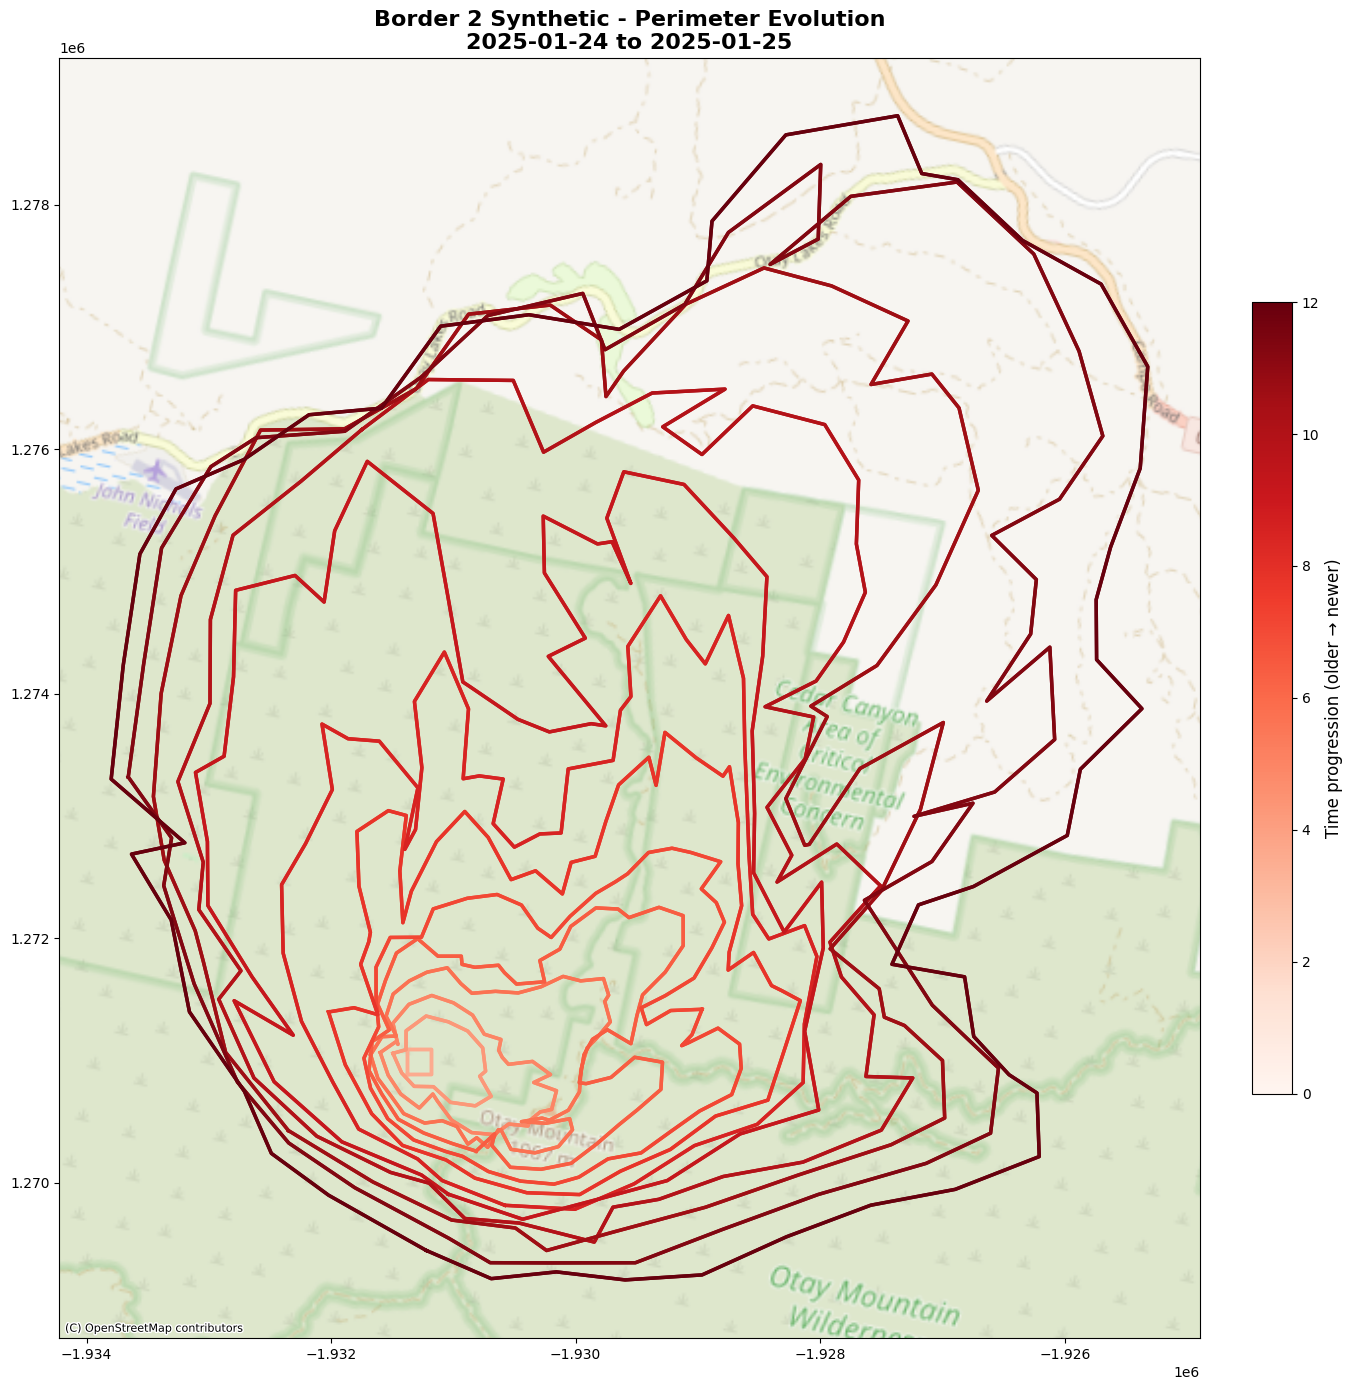

In [20]:
# Plot fire growth over time
plot_perimeter_evolution(perimeters_gdf, fire_name=FIRE_NAME)

## 2.7 Fetch Weather Data

In [21]:
# Get weather station location from fire centroid
wx_lat, wx_lon = get_weather_location_from_fire(perimeters_gdf, to_wgs84=True)

print(f"Weather query location: {wx_lat:.4f}, {wx_lon:.4f}")

Weather query location: 32.5959, -116.8571


In [22]:
# Fetch weather for entire fire duration
weather_data = fetch_weather_data(
    lat=wx_lat,
    lon=wx_lon,
    start_time=timeline['ignition_date'],
    end_time=timeline['containment_date'],
    verbose=True
)

Querying weather data...
  Location: 32.5959, -116.8571
  From: 2025-01-24T13:00:00
  To: 2025-01-25T01:00:00

✓ Retrieved 59 weather observations
  Wind speed: 0.8 - 10.4 mph (mean: 5.0)
  Wind direction: 62 - 255° (mean: 131)


## 2.8 Visualize Weather Data

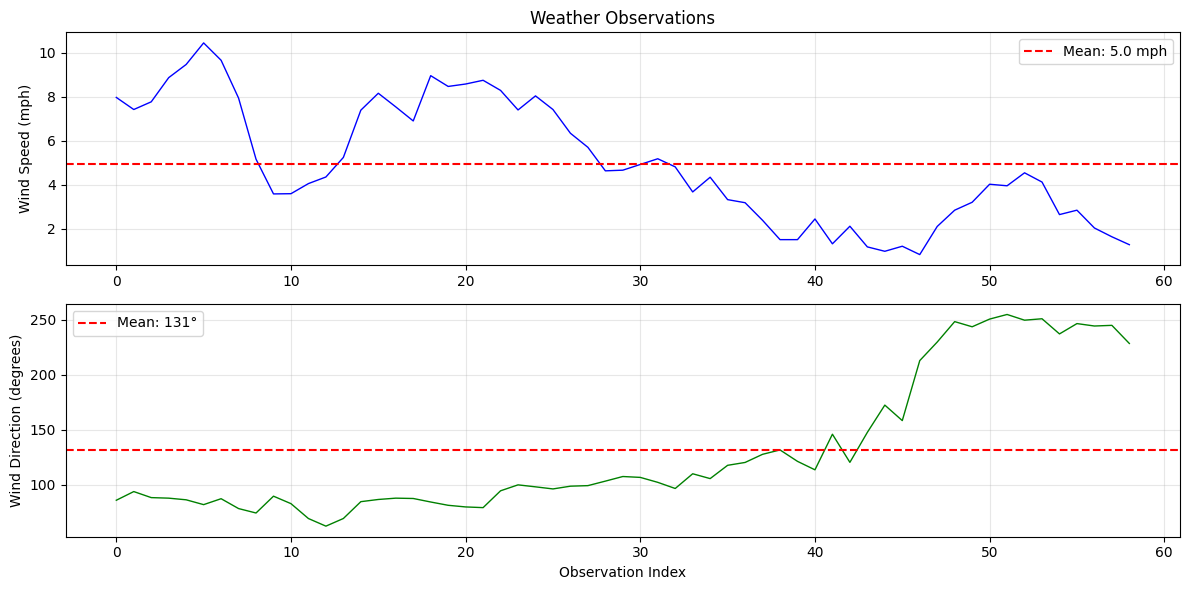

In [23]:
# Plot weather observations
plot_weather_data(weather_data)

## 2.9 Save All Data

In [24]:
YEAR = 2025

# ── Extract timeline ──────────────────────────────────────────────────────
ignition_date    = perimeters_gdf['datetime'].iloc[0]
containment_date = perimeters_gdf['datetime'].iloc[-1]
duration_days    = (containment_date - ignition_date).days

print(f"Ignition:    {ignition_date}")
print(f"Containment: {containment_date}")
print(f"Duration:    {duration_days} days")

# ── Get weather query location (centroid of first perimeter in WGS84) ─────
first_perim_wgs84 = perimeters_gdf.iloc[[0]].to_crs("EPSG:4326")
centroid = first_perim_wgs84.geometry.centroid.iloc[0]
wx_lat, wx_lon = centroid.y, centroid.x

# ── Save config ───────────────────────────────────────────────────────────
workflow_config = {
    "fire_name":         FIRE_NAME,
    "year":              YEAR,
    "lcp_path":          str(LCP_PATH),
    "ignition_date":     ignition_date.isoformat(),
    "containment_date":  containment_date.isoformat(),
    "duration_days":     duration_days,
    "n_perimeters":      len(perimeters_gdf),
    "perimeters_path":   str(perimeters_path),
    "weather_location":  {"lat": wx_lat, "lon": wx_lon},
    "data_source":       "WIFIRE Firemap WFS (view_historical_fires)"
}

config_path = DATA_DIR / "workflow_config.json"
with open(config_path, 'w') as f:
    json.dump(workflow_config, f, indent=2)

print(f"✓ Config saved to {config_path}")
print(json.dumps(workflow_config, indent=2))

Ignition:    2025-01-24 13:00:00
Containment: 2025-01-25 01:00:00
Duration:    0 days
✓ Config saved to /home/jovyan/work/WIFIRE-Digital-Twinners/wildfire-digital-twin/data/workflow_config.json
{
  "fire_name": "Border 2 Synthetic",
  "year": 2025,
  "lcp_path": "landscape.lcp",
  "ignition_date": "2025-01-24T13:00:00",
  "containment_date": "2025-01-25T01:00:00",
  "duration_days": 0,
  "n_perimeters": 13,
  "perimeters_path": "/home/jovyan/work/WIFIRE-Digital-Twinners/wildfire-digital-twin/outputs/border_2_synthetic_perimeters.geojson",
  "weather_location": {
    "lat": 32.59588662537945,
    "lon": -116.85708741551528
  },
  "data_source": "WIFIRE Firemap WFS (view_historical_fires)"
}


/tmp/ipykernel_13075/2344302775.py:14: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  centroid = first_perim_wgs84.geometry.centroid.iloc[0]


## 2.10 Summary

In [25]:
# Print summary
print("\n" + "="*60)
print(f"DATA PREPARATION SUMMARY")
print("="*60)
print(f"\nFire: {FIRE_NAME} ({YEAR})")
print(f"Data source: WIFIRE Firemap WFS")
print(f"\nPerimeters:")
print(f"  Total updates: {len(perimeters_gdf)}")
print(f"  Ignition:    {timeline['ignition_date']}")
print(f"  Containment: {timeline['containment_date']}")
print(f"  Duration:    {timeline['duration']}")
print(f"\nPerimeter progression:")
for i, row in perimeters_gdf.iterrows():
    print(f"  [{i}] {row['datetime'].date()}  —  {row.geometry.area/1e6:.2f} km²")
print(f"\nWeather query location: {wx_lat:.4f}, {wx_lon:.4f}")
print(f"\nSaved files:")
print(f"  - {perimeters_path}")
print(f"  - {config_path}")


DATA PREPARATION SUMMARY

Fire: Border 2 Synthetic (2025)
Data source: WIFIRE Firemap WFS

Perimeters:
  Total updates: 13
  Ignition:    2025-01-24 13:00:00
  Containment: 2025-01-25 01:00:00
  Duration:    0 days 12:00:00

Perimeter progression:
  [0] 2025-01-24  —  0.04 km²
  [1] 2025-01-24  —  0.38 km²
  [2] 2025-01-24  —  0.94 km²
  [3] 2025-01-24  —  2.03 km²
  [4] 2025-01-24  —  3.49 km²
  [5] 2025-01-24  —  5.74 km²
  [6] 2025-01-24  —  9.00 km²
  [7] 2025-01-24  —  13.72 km²
  [8] 2025-01-24  —  21.99 km²
  [9] 2025-01-24  —  31.39 km²
  [10] 2025-01-24  —  39.84 km²
  [11] 2025-01-25  —  49.62 km²
  [12] 2025-01-25  —  55.94 km²

Weather query location: 32.5959, -116.8571

Saved files:
  - /home/jovyan/work/WIFIRE-Digital-Twinners/wildfire-digital-twin/outputs/border_2_synthetic_perimeters.geojson
  - /home/jovyan/work/WIFIRE-Digital-Twinners/wildfire-digital-twin/data/workflow_config.json
